# Project


This project investigates the causal impact of advertising intensity on user engagement in a music streaming platform using data structured similarly to the **Pandora ad experiment**. The main objective of the project was to understand how increasing advertisement exposure affects users’ listening behavior and how this effect evolves across time and demographic groups. Using a large panel dataset of users observed over multiple weeks, the analysis moved beyond a simple treatment-versus-control comparison and focused on treatment dosage, dynamic treatment effects, non-compliance, instrumental variables, and heterogeneous treatment effects.

The project first examined **how different levels of intended ad load affected weekly listening time at the end of the experiment.** By comparing multiple treatment cells to the control group and estimating continuous dose-response regressions, the analysis showed that higher intended ad exposure reduced listening time, especially for users exposed to high ad intensity. The study then expanded to the full panel structure of the dataset to investigate how treatment effects evolved over time. Weekly regressions demonstrated that the negative impact of advertising gradually strengthened and stabilized after many weeks, suggesting the existence of cumulative ad fatigue and dynamic behavioral adaptation.

A central challenge in the project was **imperfect treatment realization (non-compliance).** Although users were randomly assigned to different intended ad loads, the actual ad exposure users received differed because of listening behavior and platform delivery dynamics. To address this endogeneity problem, the project implemented an instrumental variable (IV) framework using intended ad load as an instrument for actual ad exposure. First-stage regressions confirmed that randomized intended dosage strongly predicted actual ads received, while two-stage least squares (2SLS) estimation showed that the causal effect of actual ad exposure on listening time was more negative than suggested by naive reduced-form regressions.

Finally, the project explored heterogeneous treatment effects across demographic groups, particularly age categories. Interaction models and subgroup-specific IV analyses revealed substantial differences in sensitivity to advertising. Users aged 25–54 showed the strongest negative response to ad intensity and also exhibited the largest difference between reduced-form and IV estimates, indicating that non-compliance affected this group most strongly. Overall, the project demonstrates how experimental design, panel data analysis, instrumental variables, and interaction models can be combined to study causal behavioral responses in digital platform environments.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.sandbox.regression.gmm import IV2SLS
from scipy.stats import ttest_ind

In [2]:
df=pd.read_csv('pandora_ad_data.csv')
df

,Unnamed: 0,user_id,city,sex,age,cell,week,interruptions,ads_per,ad_min_actual,play_min
0,0,0,Los Angeles,F,18-24,8,0,9,1.5,8.502471,0.000000
1,1,0,Los Angeles,F,18-24,8,1,9,1.5,3.879412,0.000000
2,2,0,Los Angeles,F,18-24,8,2,9,1.5,5.923588,0.000000
3,3,0,Los Angeles,F,18-24,8,3,9,1.5,5.110541,434.683385
4,4,0,Los Angeles,F,18-24,8,4,9,1.5,3.964341,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
5375995,5375995,47999,Phoenix (Prescott),M,55+,0,107,4,1.5,0.588026,32.435455
5375996,5375996,47999,Phoenix (Prescott),M,55+,0,108,4,1.5,0.000000,325.534004
5375997,5375997,47999,Phoenix (Prescott),M,55+,0,109,4,1.5,1.118904,404.196913
5375998,5375998,47999,Phoenix (Prescott),M,55+,0,110,4,1.5,2.110204,0.000000


# Setup:

- **user_id**:  a unique identifier for each user: track the SAME user across multiple weeks(the data is panel)
- **city**: the city a user resides in
- **sex**: the sex of the suer
- **age**: the age of the user (bucketed into 4 age groups)  ['13-17', '18-24', '25-54', '55+']
- **cell**: an integer 0-9 representing the cell the user was allocated to. Cell 0 is the control cell and cells 1-9 are different treatments
- **week** the week of the experiment for which we are looking at data
- **interruptions** the number of interruptions Pandora *intends* to deliver based on the cell designation
- **ads_per** the number of ads per interruption Pandora *intends* to deliver based on the cell designation
- **ad_min_actual** the number of minutes of ads per hour the Pandora actually delivered to the user in a week
- **play_min**: the number of minutes a user listened to Pandora in the week


**The important point about the data is the data is panel which means we have sevral rows or observations from the same users and also the tretament(cell) is the same whithin each user across time and interuption and per add are also same as well.**

The these variables like cell have not change across time for each user because they wanted clean causal identification.
if they change the value of the cell for each user across time then there would be **Carry over Effects** which means like 
user 1 gets heavy ads in week 1 and low ads in week 2 but If listening drops in week 2 is  because week 2 low ads 
OR annoyance accumulated from week 1 heavy ads. Then it would be very hard to separate.

Another problem is **Adaptation** Users may get used to ads, become increasingly annoyed, change listening habits gradually
Changing dosage constantly mixes these effects together.

But what they did is very clean comparison. But Even though dosage is fixed they can make it dynmaic like :

$$
play\_min_{it}
=
\beta_0
+
\beta_1 \, treatment_i
+
\beta_2 \, week_t
+
\beta_3 \, (treatment_i \times week_t)
+
\epsilon_{it}
$$


using week as interaction. 



$$
\beta_1
$$

**Baseline treatment effect.**

---

$$
\beta_2
$$

**Overall time trend.**

Maybe all users reduce listening over time.

---

$$
\beta_3
$$
**whether treatment effect changes over time.** like :

- heavy ads become more annoying over weeks  
- users adapt to ads  
- treatment fatigue accumulates  

---

As aresult: 

We do NOT need changing treatment to study dynamics. We only need **repeated outcomes over time.** That is exactly why panel data is powerful. The natture of the panel data which is time can itself make treatment change over time. 

We could hace changed tretament effect across time and this would be **dynamic treatment assignment.** which can be Much more complicated and harder to interpret causally.

# Non-Complier and IV 


In this project we want to study how Actual-ad-min can affect Lisitining-time :
    
$$
\text{listening time} \sim \text{actual ad minutes}
$$

But the problem is that we can not capture the **causality** in this regression and it would be just a simple corrolational regression because there is a bias or  endogenity coming from omitted variable bias and reverse causlaity. For exmaple heavy users can listen for a long time and gets more adds and light users listen for a short time and get few adds. So here user behaviors (Listining behaviors) can bias the regression and we need to control for it.

$$
\text{actual ad minutes}
\leftrightarrow
\text{listening minutes}
$$

$$
\text{actual ad minutes}
\;\longleftarrow\;
\text{user behavior}
\;\longrightarrow\;
\text{listening minutes}
$$


Not having User behaviors can cause endogenity. 


we can control for it by simply include the type of the user like a dummy variable who is light and who is heavy users. But the simpler and clean one is using variable named tretament effect which is randomly assigned to the usres which in this 
project is cell variable. 


By assigning randomly treatment to user we can say that now **1-that assignment or teatment variable has no relationship with dendent variable or listening minutes** but **2-it is directly related with independent variable or actual ad minute** because in cell value like 9 means more intervention and more add time which means more actual ad minutes both of them are related directly to the time or length of the adds. 


Now instead of seeing just hevay users are the main user with longer ads time and just light users with shorter ads time , we can see four almost complete random situation that:

- 1- Heavy users may get shorter add intervention 
- 2- Heavy users may get longer add intervention 
- 3- light users may get shorter add intervention 
- 4- light users may get longer add intervemtion. 

Now through randomly assigning intervention (cell) to user based on the Two mentioned condition we can say :

The causal chain becomes:

$$
\text{cell assignment}
\rightarrow
\text{actual ad minutes}
\rightarrow
\text{listening time}
$$

Meaning:

- randomized assignment changes actual ads  
- actual ads affect listening  

By this assignment and considering the two condition we not only address omitted variable bias problem regarding user listining behaviors but also we addres the reverse cauasality as shown above by direction of arrows. 

Now after this original and initial randomization, we are observing we have another problem that can hurt or break the random assignment process or causality (not initial randomization which is perfectly influencial for addressing omitted variable bias issue) which is the problem of the non-compliers. 


A non-complier is someone whose: **actual treatment received differs from assigned treatment.**
or in other words they do not stick to their treatment during the expriment so they can hurt the power of the causality and randomization because in randomization we believe and expect that they are tretaed people and they should stick to their treatment. 

or 

we can say initial randomization will be fine but actual treatment is no longer determined purely by random assignment and may partly depend on user behavior. This weakens our ability to directly estimate the causal effect using actual treatment alone. Actual treatment would be purely random assignment if almost all all treated people stick to treatment othersise some treated user acts as control useres. 


In the design of the expriment we have two main component that can hurt or guarantee the randomization:

**intended treatment** which comes from cell assignment which is sth that we alreday decide who should get tretaed and how much they should be treated . 

**actual treatment recieved** which comes from actual add min and it is how much tretaed group has recived their treatment. 

In most of the real-world cases users do not perfectly receive **Intended treatment**. Because actual exposure depends partly on user behavior. for example: If a user listens longer: they naturally encounter more ad thus ad_min_actual increases

So now ad_min_actual is partly determined by play_min or by the same hidden user traits affecting listening.

This gets us back again to the square one with the problem of Reverse causality / endogeneity. 


So if we can have :

$$
\text{Assigned dosage}
=
\text{Actual dosage}
$$

then we can say the treated group stick to their treatment and there is no problem of non-compliers and the intiial or original ranomization will not be broken and we are good. 


but if :


$$
\text{Assigned dosage}
\neq
\text{Actual dosage}
$$


Even we assigned tretament randomly we will have the problem of the non compliers which hurts intial random assignment and this can happen because of :

- listening duration  
- system delivery  
- user behavior  
- session endings  
- etc.  



### Example : Clear Non-Complier

| User | Assigned Cell | Intended Ads | Actual Ads |
|---|---|---|---|
| A | Heavy-ad cell | 12 min/hour | 2 min/hour |

Why might this happen?

Because:

- user exits early  
- skips sessions  
- buffering  
- inactive app  
- technical delivery issues  

This user did NOT receive intended exposure.

That is: **non-compliance**

---

### Example 2 : Complier

| User | Assigned Cell | Intended Ads | Actual Ads |
|---|---|---|---|
| B | Heavy-ad cell | 12 min/hour | 11.5 min/hour |

This user basically complied with assignment.



Now the question is that how we can address the the problem of the non-complier.

For solving it we use a technique named Instrumental variable (IV). Fortunately this technique in RCT is a way easier than in non-random or quasi-exprimental method because random assignment of the treatement pave the way for conducting this technique easier.

There are two main condition to use a proper IV which because this project is RCT this two conditions or requirments have been alreday met. 

### 1. Relevance

The instrument must affect: **actual ads received.**

Meaning:

$$
\text{cell assignment}
\rightarrow
\text{actual ad minutes}
$$

This condition is satisfied because: **higher-ad cells deliver more ads on average.**

So the instrument genuinely changes the treatment intensity.

---

### 2. Exogeneity

The instrument must NOT directly depend on **user listening preferences.**

Because: **users were randomly assigned to cells.**

So:

$$
\text{cell assignment}
\not\leftrightarrow
\text{user preferences}
$$

Meaning **the instrument is independent of underlying user behavior.**

---

This is the critical causal identification assumption. It means: **the only reason cell assignment changes listening outcomes is through its effect on actual ads.**

So IV isolates **clean random variation in ads,** which allows us to estimate the causal effect of ads on listening behavior.

As we alreday mentioned the tretament variable (cell in this project) meet both these requirments and so it is a valid and credible IV. 


---

## OLS vs IV 

### OLS asks:  

**“Users who got more ads — did they listen less?”**

#### Problem

Users who got more ads may simply be: **heavy listeners.** So the relationship may reflect:

- user behavior  
- not causal effect of ads  


### IV asks:

**“Users RANDOMLY pushed into higher-ad cells — did they listen less?”**

That is much closer to: **causal inference.**

---

## With IV vs Without IV 


### Without IV

$$
\text{actual ad minutes}
\leftrightarrow
\text{listening minutes}
$$

This relationship may be **biased.**

Because user behavior can affect both:

- listening time  
- and ads received  

---

### With IV

$$
\text{cell assignment}
\rightarrow
\text{actual ad minutes}
\rightarrow
\text{listening minutes}
$$

Now the variation in:

$$
\text{actual ad minutes}
$$

comes only from: **random assignment.**

So IV isolates: **clean causal variation in ads.


--- 

## How IV works 


###  First Stage

Random assignment affects actual ads:

$$
ad\_min\_actual
=
\pi_0
+
\pi_1 \, cell
+
u
$$

By the first stage we kind of trying to get compliers from the original data or randomization because we are looking for just users whose ad_min_actual has relationship with treatment(cell) and throw away some data or part of the variation that do not follow the is relationship. So the first stage by itslef reduce the variation of the main data by thrwoing away some useless data that create bias. 
 
 More precisely IV reduces usable variation. because it ignores:

- endogenous variation
- behavioral variation
- noisy variation

and only keeps: **exogenous variation**


But OLS uses ALL variation in:

$$
ad\_min\_actual
$$

Meaning:

$$
ad\_min\_actual
=
\text{randomized variation}
+
\text{behavioral variation}
+
\text{noise}
$$

OLS keeps everything That gives:

- more variation  
- more statistical power  

BUT: **possibly biased estimates.**


So the important part of the IV is the first satge to make the the regression cleans and close to causality. 

---

### Second Stage

Predicted ads affect listening:

$$
play\_min
=
\beta_0
+
\beta_1 \widehat{ad\_min\_actual}
+
\varepsilon
$$

where:

$$
\widehat{ad\_min\_actual}
$$

contains ONLY the randomized part of ad exposure.

is the predicted component of ad exposure generated only from the randomized assignment.
contains ONLY the randomized part of ad exposure.




### What IV Does

IV isolates ONLY this part: **variation in ads caused by assignment**

and ignores: **the behavioral/noisy part.**

---

### The Hidden Decomposition

We can think of actual ads as:

$$
ad\_min\_actual
=
\underbrace{\text{randomized component}}_{\text{from cell assignment}}
+
\underbrace{\text{behavioral component}}_{\text{endogeneity}}
$$

**OLS** uses BOTH parts. That causes bias.

**IV** Keeps Only **randomized component**

because that part is **causal.**


### As a short note: 

IV is NOT: **“fixing randomization.”** The original randomization is already fine.

IV is fixing: **contamination in actual treatment exposure.**



As a conclusion initial randomization solve solve endogentity like omitted variable bias or reverse causality but it is the seconf process or IV that solve non-compliers issue and also it is good to mention  IV still solves an endogeneity problem,
BUT that endogeneity was caused by non-compliance or the endogenity or omitted variables that cause the users to be non-complient. 

# In the following code 

We are going to use multiple cells of a test to estimate the impact of the dose of a treatment. Here we will examine only the final time period of the expereiment.

For this problem we are going to examine only data at the end of an experiment. we only take the data from the last week of the experiment and then we will see  how many weeks are there in the experiment and how many users are there per week?

So we will convert panal data into cross sectional data in which we will have just one obe or row from each users. 

In [5]:

# Last week of experiment
last_week = df["week"].max()

# only observations from last week
df_end = df[df["week"] == last_week]

# Preview
df_end.head()


# Number of weeks

num_weeks = df["week"].nunique()

print("Number of weeks:", num_weeks)

# Number of users per week

users_per_week = df.groupby("week")["user_id"].nunique()

print(users_per_week)

Number of weeks: 112
week
0      48000
1      48000
2      48000
3      48000
4      48000
       ...  
107    48000
108    48000
109    48000
110    48000
111    48000
Name: user_id, Length: 112, dtype: int64


# The following code

We have 10 cells in this experiment, a control (Cell= 0) and 9 treatment cells. For each cell in the experiment, we will calculate change in played minutes between control and that particular cell, and use a difference in means t-test to state whether the change was statistically significantly different from 0.

In [7]:


results = []

# Looping through treatment cells 1 to 9
for c in range(1, 10):

    # only control and current treatment cell
    temp = df_end[df_end["cell"].isin([0, c])]

    # control
    control = temp[temp["cell"] == 0]["play_min"]

    # treatment 
    treatment = temp[temp["cell"] == c]["play_min"]

   
    diff = treatment.mean() - control.mean()

   
    t_stat, p_value = ttest_ind(treatment, control)

 
    results.append({
        "cell": c,
        "difference_in_means": diff,
        "p_value": p_value
    })


results_df = pd.DataFrame(results)

results_df["significant"] = results_df["p_value"] < 0.05

results_df

,cell,difference_in_means,p_value,significant
0,1,6.724720,0.323765,False
1,2,0.254460,0.969836,False
2,3,-1.126452,0.865864,False
3,4,2.225470,0.741515,False
4,5,-1.961315,0.770531,False
5,6,-9.869613,0.142334,False
6,7,-4.447233,0.508569,False
7,8,-24.502895,0.000246,True
8,9,-22.309013,0.000777,True


# Interpretation

The result showing that low and medium ad dosages do not significantly reduce listening time. But **very high ad dosages (cells 8 and 9)** and **cause a statistically significant drop in listening.**

---

This makes sense because users may tolerate:

- low ads  
- moderate interruptions  

But after some threshold **ad fatigue appears** and listening behavior drops sharply. This is a classic **nonlinear dose-response relationship.**

---

Even though some effects are negative, they may not be statistically significant because:

- effect size is small  
- user behavior is noisy  
- overlap between groups is large  

Like Cell 6:

$$
-9.87
$$

looks economically meaningful, but variability is large enough that the p-value is still above:

$$
0.05
$$

---

This experiment suggests **small increases in ads may not hurt engagement much but aggressive ad intensity can substantially reduce listening time.**

That is extremely valuable for platforms like Pandora Media because it helps the to optimize: 

- monetization  
- user retention  
- ad load policy  

---

As aresult we can say that for cells 8 and 9:

$$
p < 0.05
$$

So we reject:

$$
H_0 : \text{Difference} = 0
$$

the reduction in listening is statistically distinguishable from random noise and the negative difference shwoing **diminishing tolerance behavior.** means Users tolerate ads up to a point, then suddenly engagement falls, which is common in streaming, social media, subscription platforms, online advertising systems.




# In the following code:

Now we will create new column with the expected ad load per hour named “treated_ad_min”, where we combine “ads_per” and “interruptions” to the total intended minutes of ads per hour. Assuming each ad is 0.5 minutes (30 seconds)
We will Run a linear a regression where the outcome is play_min and the independent variable is treated_ad_min. Then we will see what is coefficient on treated_ad_min and wether it is statistically significant at 95% confidence.

In [9]:
# Each ad is 0.5 minutes


df_end = df[df["week"] == last_week].copy()

# Here we turned cell or treatment variables to the actual time that advertise play for the users. 
# so no need to seperates different geoup of the tretament bsed on their dosage like above one. 
# we can say for exmaple user with doage 7 has 5 interuptions and 3 adds which lasted 30 second for each add during a week.
# and user with doage 3 has 2 interuptions and 2 adds which lasted 30 second for each add during a week.
df_end["treated_ad_min"] = df_end["ads_per"] * df_end["interruptions"] * 0.5


model = smf.ols(
    "play_min ~ treated_ad_min",
    data=df_end
).fit()

print(model.summary())

coef = model.params["treated_ad_min"]
p_value = model.pvalues["treated_ad_min"]

print("Coefficient on treated_ad_min:", coef)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant at 95% confidence")
else:
    print("Not statistically significant at 95% confidence")
    
    
    
# Notice so far we have just used cross sectional data(last week from each users).

                            OLS Regression Results                            
Dep. Variable:               play_min   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     26.15
Date:                Wed, 20 May 2026   Prob (F-statistic):           3.17e-07
Time:                        15:26:37   Log-Likelihood:            -3.4625e+05
No. Observations:               48000   AIC:                         6.925e+05
Df Residuals:                   47998   BIC:                         6.925e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        359.1091      4.265     84.

# Interpertation :

$$
play\_min_i
=
359.11
-
6.27 \times treated\_ad\_min_i
+
\epsilon_i
$$

where:

- play_min_i= actual listening minutes for user i 
- treated_ad_min_i = intended ad minutes per hour  
- epsilon_i = everything not captured by the model  

---

Intercept is 359.11 which means: **when intended ad load is 0, expected listening time is about 359 minutes.**

So users in the control/no-ad condition are predicted to listen around **359 minutes** on average.

---

The coefficient is -6.27 means each additional intended ad-minute per hour is associated with about 6.27 fewer listening minutes.

For exmaple 

If Pandora increases intended ad load from  2 ad-minutes/hour to 3 ad-minutes/hour then predicted listening decreases by roughly 6.27 minutes.

---


P-value is far below 0.05 So the coefficient is **statistically significant at 95% confidence.** Meaning:the negative relationship between intended ads and listening is extremely unlikely to be due to random chance.

---

R sqaure is very low like  0.1% which showing model  explain low level of variation in listening behavior.
But it is not a big deal because human behavior is very noisy and listening time depends on many things like music preference , mood  , time availability,habits,work schedule,engagement and a single treatment variable rarely explains a large share of behavior. The most important point is the p value for tretament efffcet is significant. 


# In the following code 

Now we will calculate the treatment effect (minutes of ad load on time played) for each week of the experiment and we will create a graph of time series of treatment effects. **This would be for the whole data.**


   week  treatment_effect
0     0         -0.651095
1     1         -0.331240
2     2         -0.443183
3     3         -0.244138
4     4         -1.176131


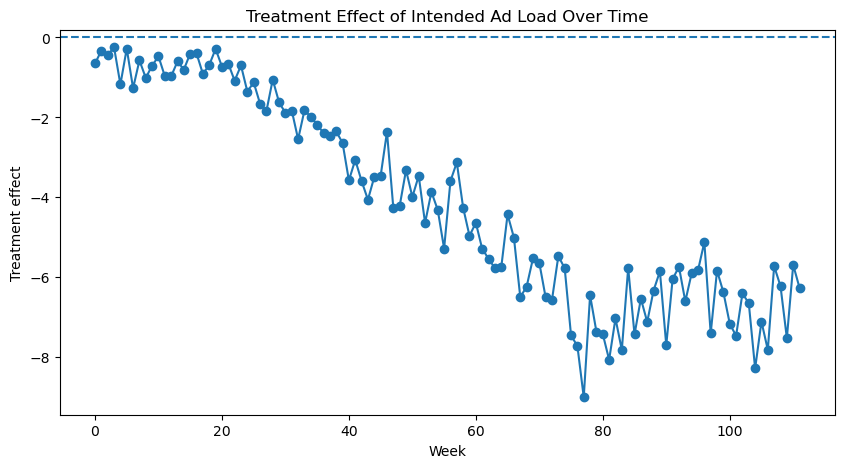

In [14]:
import matplotlib.pyplot as plt

# Re-creating treated_ad_min in the full dataframe
df["treated_ad_min"] = df["ads_per"] * df["interruptions"] * 0.5


weekly_results = []

for w in sorted(df["week"].unique()):

    # Keeping only data from one week
    df_small = df[df["week"] == w].copy()

    
    mod = smf.ols(
        formula="play_min ~ treated_ad_min",
        data=df_small
    )

    res = mod.fit()

    # Extracting coefficient on treated_ad_min
    coef = res.params["treated_ad_min"]

    # Storing result
    weekly_results.append({
        "week": w,
        "treatment_effect": coef
    })


weekly_effects = pd.DataFrame(weekly_results)

print(weekly_effects.head())

plt.figure(figsize=(10, 5))
plt.plot(
    weekly_effects["week"],
    weekly_effects["treatment_effect"],
    marker="o"
)

plt.axhline(y=0, linestyle="--")
plt.xlabel("Week")
plt.ylabel("Treatment effect")
plt.title("Treatment Effect of Intended Ad Load Over Time")
plt.show()

# For the following code

we will calculate the t-stat for the treatement effect (minutes of ad load on time played) for each week of the experiment. and then we will create a graph of time series of the t-stats

   week    t_stat   p_value
0     0 -0.519725  0.603258
1     1 -0.348340  0.727587
2     2 -0.331432  0.740320
3     3 -0.157944  0.874501
4     4 -1.157872  0.246922


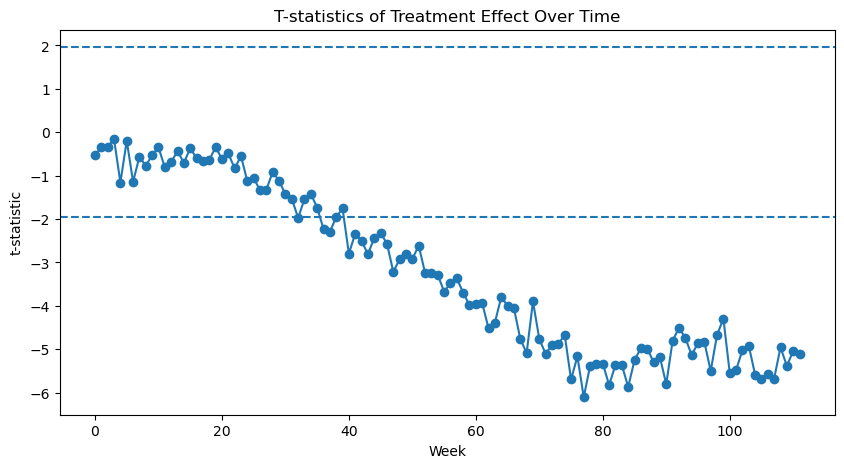

In [15]:

weekly_tstats = []


for w in sorted(df["week"].unique()):

    
    df_small = df[df["week"] == w].copy()

    
    mod = smf.ols(
        formula="play_min ~ treated_ad_min",
        data=df_small
    )

    res = mod.fit()

    
    t_stat = res.tvalues["treated_ad_min"]

    
    p_value = res.pvalues["treated_ad_min"]

   
    weekly_tstats.append({
        "week": w,
        "t_stat": t_stat,
        "p_value": p_value
    })


weekly_tstats_df = pd.DataFrame(weekly_tstats)


print(weekly_tstats_df.head())

plt.figure(figsize=(10,5))

plt.plot(
    weekly_tstats_df["week"],
    weekly_tstats_df["t_stat"],
    marker="o"
)


plt.axhline(y=1.96, linestyle="--")
plt.axhline(y=-1.96, linestyle="--")

plt.xlabel("Week")
plt.ylabel("t-statistic")
plt.title("T-statistics of Treatment Effect Over Time")

plt.show()

# Interpertation 

(Each point is all obervation in a given week.In other word, the difference of the mean for between treatment and control.)

### Treatment Effect Graph

The graph shows **Effect of intended ad load on listening time** over weeks.


At the beginning treatment effect is close to 0 and ads have little impact Then gradually **effect becomes more negative**
Eventually stabilizing around:

$$
-6 \text{ to } -7
$$

minutes.


This suggests **ad fatigue accumulates over time.** At first users tolerate ads, but after many weeks higher ad load significantly reduces listening behavior.

The important dynamic insight is that the effect is NOT immediate. Instead:

$$
Treatment\ Effect_t
\downarrow
\text{ gradually over time}
$$

This is a classic **dynamic treatment effect.**



---

### 2 :T-stat Graph

This graph shows **statistical strength of the treatment effect over time.**

What We Observe in early weeks :

> t-stats are between 0 and -1.5  
> not statistically significant

Then around roughly:

$$
week \approx 35
$$

the t-stat crosses:

$$
-1.96
$$

which corresponds to 5% significance level.


This means **the experiment only begins detecting statistically reliable evidence after many weeks.**  treatment effect itself became stronger over time**Not necessarily because sample size changed.** Users gradually reacted more negatively to ads.

So this experiment teaches **short experiments may miss long-run behavioral effects.** If Pandora stopped too early they might conclude: “Ads do not hurt engagement.” But long-run data reveals:

- cumulative annoyance  
- adaptation / fatigue effects  


Both graphs suggest stabilization occurs roughly around:

$$
week \ 70\text{–}80
$$

with treatment effect stabilizing near:

$$
-6 \text{ to } -7
$$

minutes.

---

Like many other project we can ask **What happens if you stop at first significance?** If researchers continuously monitor significance and stop immediately once:

$$
p < 0.05
$$

then **alse positive risk increases.** This is called:

- early stopping problem  

or

- repeated testing problem.


So the significance crossing appears meaningful because the effect continues afterward but in many experiments:**temporary fluctuations can falsely trigger significance.** That is why:

- pre-registered stopping rules  
- alpha spending  
- Bayesian monitoring  

are important in experimentation.

# The following code :

Here we will focus on results at the end of the experiment(Last week) and we will Create a scatter plot of "treated_ad_min" against “ad_min_actual” for each user and also we will use the groupby method on a data frame to create a table that shows the mean ad_min_actual for every unique treated_ad_min. 

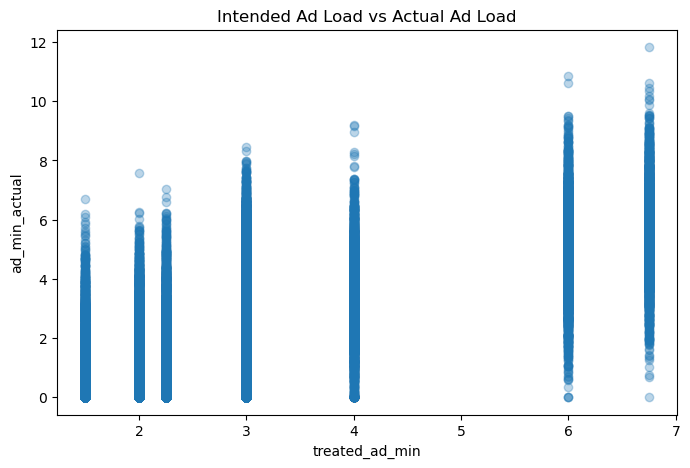

,treated_ad_min,ad_min_actual
0,1.50,1.360815
1,2.00,1.737821
2,2.25,1.876501
3,3.00,2.487349
4,4.00,3.361121
5,6.00,4.963919
6,6.75,5.611792


In [17]:

plt.figure(figsize=(8,5))

plt.scatter(
    df_end["treated_ad_min"],
    df_end["ad_min_actual"],
    alpha=0.3
)

plt.xlabel("treated_ad_min")
plt.ylabel("ad_min_actual")
plt.title("Intended Ad Load vs Actual Ad Load")

plt.show()

# Mean actual ads for each


ad_table = df_end.groupby(
    "treated_ad_min"
)["ad_min_actual"].mean().reset_index()

ad_table

# Interperation :

As:

$$
treated\_ad\_min
$$

increases,

the average:

$$
ad\_min\_actual
$$

also increases.

So the intended dosage clearly affects actual dosage. so **the instrument is relevant**

---

For each intended dosage level **there is a large vertical spread.**  which means some users receive:

- very low actual ads  
- medium actual ads  
- very high actual ads  

This means users assigned the SAME intended treatment **do NOT receive the same actual treatment.** This is exactly **imperfect compliance.**


The scatter plot shows:

$$
treated\_ad\_min
\rightarrow
ad\_min\_actual
$$

is positive, BUT noisy.


But Actual ads are ALWAYS lower than intended ads. This strongly suggests:

- users do not fully receive planned ads  
- exposure is diluted  
- non-compliance exists  


This graph is basically visual evidence for **first-stage relevance.**

Meaning:

$$
Cov(treated\_ad\_min,\ ad\_min\_actual)
\neq
0
$$

which is required for a valid IV.

So we can say Pandora planned ad intensity successfully shifts actual ad exposure BUT **user behavior and delivery realities prevent perfect implementation.** That is exactly why:

$$
ad\_min\_actual
$$

becomes endogenous and IV becomes useful.

# Coding part 

Now we want to run a regression where “ad_min_actual” is the outcome and “treated_ad_min” is the independent variable and then look at the coefficient to know wether it is a “strong” instrument by checking at the R-squared in this regression.
and also we run a regression where “play_min” is the outcome and “treated_ad_min" is the independent variable.

In [25]:
# First-stage regression
first_stage = smf.ols(
    "ad_min_actual ~ treated_ad_min",
    data=df_end
).fit()

print(first_stage.summary())

#  coefficient
beta_fs = first_stage.params["treated_ad_min"]

print("First-stage coefficient:", beta_fs)

# Extracting R-squared
r2_fs = first_stage.rsquared

print("R-squared:", r2_fs)


# Reduced-form regression

reduced_form = smf.ols(
    "play_min ~ treated_ad_min",
    data=df_end
).fit()

print(reduced_form.summary())

# Extracting coefficient
beta_rf = reduced_form.params["treated_ad_min"]

print("Reduced-form coefficient:", beta_rf)

# Wald / IV ratio

iv_ratio = beta_rf / beta_fs

print("IV ratio:", iv_ratio)

                            OLS Regression Results                            
Dep. Variable:          ad_min_actual   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                 2.234e+04
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        14:05:08   Log-Likelihood:                -86602.
No. Observations:               48000   AIC:                         1.732e+05
Df Residuals:                   47998   BIC:                         1.732e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0449      0.019      2.

### First Regression (First Stage)

Regression:

$$
ad\_min\_actual
=
0.045
+
0.82 \times treated\_ad\_min
$$


The coefficient:

$$
0.82
$$

means **when Pandora increases intended ads by 1 additional minute per hour, users actually receive about 0.82 additional minutes of ads on average.**

It NOT Equal to 1 because of imperfect compliance.Users do not fully receive planned ads because of:

- quitting early  
- lower listening time  
- delivery imperfections  
- user behavior  

---

This is a  Strong Instrument because R square is relatively good meaning intended dosage explains about 32% of the variation in actual ads. That is reasonably strong. Also:

$$
F = 22340
$$

is extremely large which is very strong first stage.

---

### Second Regression (Reduced Form)

Regression:

$$
play\_min
=
359.1
-
6.27 \times treated\_ad\_min
$$



The coefficient:

$$
-6.27
$$

meaning **increasing intended ads by 1 minute per hour reduces listening time by about 6.27 minutes.** This is the: effect of assigned/intended treatment.

---

###  IV Ratio (Wald Estimator)


$$
\frac{-6.27}{0.82}
=
-7.65
$$


This is the IV estimate. Which means increasing ACTUAL ads by 1 minute per hour reduces listening time by about 7.65 minutes. this means if we go or we just accept intended one then we will feel that we can use longer time window for add time like we can put the threshold on 10 min but actual value showing we should put threshold on like 7 min to not hurt the listining time of the usres. 

---

IV is Larger Than Reduced Form Because **not all intended ads become actual ads** which means that some part of the intended adds did not work at all (maybe user did not exprience all time of intended adds but we thought that all time of intended adds has been seen by the users)

The first stage says **1 intended minute → 0.82 actual minutes**

So the reduced-form effect gets diluted. IV rescales the effect to reflect **actual treatment exposure**

---
 

| Component | Interpretation |
|---|---|
| Reduced form | “How does assigned dosage affect listening?” |
|  | \(-6.27\) |
| First stage | “How much does assigned dosage change actual ads?” |
|  | \(0.82\) |
| IV estimate | “How does actual ads affect listening?” |
|  | \(-7.65\) |

---


So we can say the IV estimate is stronger because it corrects for **non-compliance / imperfect treatment realization.**
Some treated users receive fewer ads than intended, so the raw treatment effect appears smaller until IV adjusts for it.

# the next part of the code :

Now we are going to use pythons 2 stage least squares function to see whay happen to the coeefcient this time. 


In [20]:
from statsmodels.sandbox.regression.gmm import IV2SLS


# Adding a constant column to the dataframe
df_end['constant'] = 1

#the endogenous and exogenous variables
endog = df_end['play_min']
exog = df_end[['ad_min_actual', 'constant']]  # Including actual ad minutes and the constant term
instrument = df_end[['treated_ad_min', 'constant']]  # Including treated ad minutes as instrument and constant term

iv_model = IV2SLS(endog, exog, instrument)
iv_results = iv_model.fit()

iv_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          IV2SLS Regression Results                           
==============================================================================
Dep. Variable:               play_min   R-squared:                       0.011
Model:                         IV2SLS   Adj. R-squared:                  0.011
Method:                     Two Stage   F-statistic:                     26.42
                        Least Squares   Prob (F-statistic):           2.76e-07
Date:                Thu, 21 May 2026                                         
Time:                        01:29:40                                         
No. Observations:               48000                                         
Df Residuals:                   47998                                         
Df Model:                           1                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
ad_min_actual    -7.6456      1.488     -5.140      0.000     -10.561      -4.730
constant        359.4523      4.306     83.470      0.000     351.012     367.893
==============================================================================
Omnibus:                     4287.311   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5560.480
Skew:                           0.833   Prob(JB):                         0.00
Kurtosis:                       3.054   Cond. No.                         6.33
==============================================================================
"""

## Interpretation

The coefficient on:

$$
ad\_min\_actual
$$

measures the causal effect of actual ad exposure on listening time after correcting for non-compliance using the randomized intended ad load as an instrument.


The coefficient is approximately:

$$
-7.6
$$

Which means increasing actual ads by 1 additional minute per hour causally reduces listening time by about 7.6 minutes.

---

This result closely match the ratio you manually calculated above. 

$$
\frac{\text{Reduced Form}}{\text{First Stage}}
=
\frac{-6.27}{0.82}
\approx
-7.65
$$

because in a single-instrument single-endogenous-variable setup:

$$
\text{IV2SLS estimate}
=
\text{Wald ratio estimate}
$$

---

So the IV estimate is usually more negative than the simple OLS/reduced-form estimate because IV corrects for imperfect treatment realization (non-compliance). 

# Next coding 

Now we are going to look at heterogeneity by different subgroups through 3 variables which describe user attributes: sex, age, and city. 

In [21]:
# age is treated as categorical
df_end["age"] = df_end["age"].astype("category")

model_age = smf.ols(
    formula="play_min ~ treated_ad_min * age",
    data=df_end
).fit()

print(model_age.summary())

                            OLS Regression Results                            
Dep. Variable:               play_min   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     763.6
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        10:45:12   Log-Likelihood:            -3.4373e+05
No. Observations:               48000   AIC:                         6.875e+05
Df Residuals:                   47992   BIC:                         6.875e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## The estimated regression is approximately:

$$
\begin{aligned}
play\_min =\;& 260.50 \\
&+ 112.61 \cdot age_{18\text{–}24} \\
&+ 221.86 \cdot age_{25\text{–}54} \\
&- 85.23 \cdot age_{55+} \\
&- 1.69 \cdot treated\_ad\_min \\
&- 5.46 \cdot (treated\_ad\_min \times age_{18\text{–}24}) \\
&- 7.10 \cdot (treated\_ad\_min \times age_{25\text{–}54}) \\
&- 2.14 \cdot (treated\_ad\_min \times age_{55+})
\end{aligned}
$$

---


The omitted/reference age group is **13–17**

So:

- intercept  
- main treatment coefficient  

belong to age 13–17.

For age 13–17: predicted listening when ads = 0:

$$
260.5
$$

minutes.

---

### Age Effects

Compared to 13–17:

| Age Group | Difference |
|---|---|
| 18–24 | +112.6 |
| 25–54 | +221.9 |
| 55+ | -85.2 |

Meaning: 25–54 users listen MUCH more and 55+ users listen less  

---

### Treatment Effects By Age

#### For Age 13–17 Treatment effect is: 

$$
-1.69
$$

Not statistically significant.

---

#### For Age 18–24 Treatment effect is :

$$
-1.69 + (-5.46) = -7.15
$$

Meaning 1 extra intended ad-minute reduces listening by about:

$$
7.15
$$

minutes with borderline significance.

---

#### For Age 25–54 treatment effect is: 

$$
-1.69 + (-7.10) = -8.79
$$

This interaction IS statistically significant. This group is the MOST sensitive to ads.

---

#### for Age 55+ Treatment effect:

$$
-1.69 + (-2.14) = -3.83
$$

Not statistically significant.

---

So different age groups react differently to ads. Especially **users age 25–54 are much more negatively affected by ads.**

This is **heterogeneous treatment effects.**

In [22]:

df_end["age"] = df_end["age"].astype("category")


model_ads_age = smf.ols(
    formula="ad_min_actual ~ treated_ad_min * age",
    data=df_end
).fit()

print(model_ads_age.summary())

                            OLS Regression Results                            
Dep. Variable:          ad_min_actual   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     3884.
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        10:47:20   Log-Likelihood:                -85000.
No. Observations:               48000   AIC:                         1.700e+05
Df Residuals:                   47992   BIC:                         1.701e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         


### Estimated regression:

$$
\begin{aligned}
ad\_min\_actual =\;& -0.40 \\
&+ 0.67 \cdot age_{18\text{–}24} \\
&+ 0.69 \cdot age_{25\text{–}54} \\
&+ 0.01 \cdot age_{55+} \\
&+ 0.80 \cdot treated\_ad\_min \\
&+ 0.03 \cdot (treated\_ad\_min \times age_{18\text{–}24}) \\
&+ 0.02 \cdot (treated\_ad\_min \times age_{25\text{–}54}) \\
&- 0.01 \cdot (treated\_ad\_min \times age_{55+})
\end{aligned}
$$

---


#### reference group = 13–17.


#### For age 13–17:

$$
1 \text{ intended ad minute}
\rightarrow
0.80 \text{ actual ad minutes}
$$

---

### Interaction Effects

#### Age 18–24

$$
0.80 + 0.03 = 0.83
$$

Statistically significant.This group receives slightly MORE actual ads.

---

#### Age 25–54

$$
0.80 + 0.02 = 0.82
$$

Slightly larger too with Weak significance.

---

#### Age 55+

$$
0.80 - 0.01 = 0.79
$$

No meaningful difference.

---

This regression suggesting **different age groups experience different realized treatment intensity.** Likely because listening behavior differs. for exmaple 

- younger/middle-age users stay longer  
- therefore receive more actual ads  

---
The most intersting insight is that  the 25–54 group

both **receives relatively high actual ad exposure**  AND **reacts most negatively to ads.** 

This suggests they are **the most economically sensitive segment to advertising load.**

# Next part of the code 

Now we will repeat the analysis we did above but for each of the 4 age groups and we will see which group has the largest change in treatment effect between the 2sls and the "reduced form" 

In [24]:


# constant for IV2SLS
df_end["constant"] = 1

results = []

# Looping over each age group
for a in df_end["age"].unique():

    
    df_age = df_end[df_end["age"] == a].copy()

    
    # Reduced form:
    # play_min ~ treated_ad_min
    
    rf = smf.ols(
        "play_min ~ treated_ad_min",
        data=df_age
    ).fit()

    rf_coef = rf.params["treated_ad_min"]

   
    # First stage:
    # ad_min_actual ~ treated_ad_min
    
    fs = smf.ols(
        "ad_min_actual ~ treated_ad_min",
        data=df_age
    ).fit()

    fs_coef = fs.params["treated_ad_min"]

    
    # 2SLS:
    # play_min outcome
    # ad_min_actual endogenous variable
    # treated_ad_min instrument
    
    y = df_age["play_min"]

    X = df_age[["constant", "ad_min_actual"]]

    Z = df_age[["constant", "treated_ad_min"]]

    iv = IV2SLS(y, X, Z).fit()

    iv_coef = iv.params["ad_min_actual"]

    # Difference between IV and reduced form
    change = iv_coef - rf_coef

    results.append({
        "age": a,
        "reduced_form_coef": rf_coef,
        "first_stage_coef": fs_coef,
        "iv_2sls_coef": iv_coef,
        "change_iv_minus_rf": change,
        "absolute_change": abs(change)
    })


age_results = pd.DataFrame(results)

# Sorting by largest change
age_results = age_results.sort_values("absolute_change", ascending=False)

age_results

,age,reduced_form_coef,first_stage_coef,iv_2sls_coef,change_iv_minus_rf,absolute_change
1,25-54,-8.792685,0.828614,-10.611314,-1.818629,1.818629
0,18-24,-7.152102,0.834767,-8.567787,-1.415685,1.415685
2,55+,-3.832311,0.793712,-4.828341,-0.996030,0.996030
3,13-17,-1.694667,0.804158,-2.107380,-0.412713,0.412713


# Interpretation 



the result showing that the 25–54 group has the largest difference between:

- reduced form estimate  
- IV / 2SLS estimate  

because:

$$
|-10.61 - (-8.79)| = 1.82
$$

largest among all groups.


This means **non-compliance matters MOST for the 25–54 group.** The naive/reduced-form estimate understated the true effect the most for this age group.

---

For EVERY age group:

$$
|IV| > |\text{Reduced Form}|
$$

Meaning after correcting for non-compliance, ads appear MORE harmful. Exactly what IV theory predicts.

---

The age of 25–54 Most Affected likely because this group:

- listens more overall  
- receives more realized ads  
- has stronger behavioral response to ads  

So imperfect treatment realization diluted the reduced-form estimate more strongly.

---

The  **25–54 demographic** appears to be the most engaged users AND the most sensitive to ad intensity. This is extremely important commercially because this group is often:

- high-value consumers  
- economically active users  
- premium advertising targets  

IV Increase Magnitude because reduced-form estimates are diluted by incomplete treatment realization.

IV isolates the causal effect of **actual ad exposure.** So the “true” ad annoyance effect becomes stronger.

---

So The results suggest that **middle-aged users (25–54) experience the strongest negative causal effect of ads,** and correcting for non-compliance using IV substantially increases the estimated magnitude of this effect.